# Lab 4 - Classification and Evaluation in NLP

Use case: sentiment analysis on Amazon reviews of unlocked phones. Each review is classified as positive, negative or neutral using TF-IDF features and a Naive Bayes classifier.

Libraries used: pandas, nltk, scikit-learn, matplotlib, kagglehub.

Install the libraries first if they are missing: `pip install pandas nltk scikit-learn matplotlib kagglehub ipywidgets`

In [1]:
import warnings
warnings.filterwarnings("ignore")  # hide the tqdm progress bar warning

import os
import re

import kagglehub
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

_ = nltk.download("stopwords", quiet=True)
_ = nltk.download("wordnet", quiet=True)

## Task 1: Load the data and do 5 preprocessing steps

In [2]:
path = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")
csv_file = [os.path.join(r, f) for r, d, fs in os.walk(path) for f in fs if f.endswith(".csv")][0]
print(csv_file)

df = pd.read_csv(csv_file)
print(df.shape)
print(df.columns.tolist())
df.head()

100%|██████████| 32.6M/32.6M [00:02<00:00, 11.5MB/s]

Extracting files...


C:\Users\GAMING\.cache\kagglehub\datasets\PromptCloudHQ\amazon-reviews-unlocked-mobile-phones\versions\1\Amazon_Unlocked_Mobile.csv
(413840, 6)
['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [3]:
# missing values
df.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

The labels come from the star rating, the same way as in the Disneyland example: above 3 is positive, below 3 is negative, and 3 is neutral. I drop the rows with a missing review or rating.

The full dataset is big (hundreds of thousands of reviews), so I take a random sample of 50,000 reviews to keep the preprocessing and training fast.

In [4]:
df = df.dropna(subset=["Reviews", "Rating"])
df = df.sample(n=50000, random_state=42).reset_index(drop=True)

df["Sentiment"] = df["Rating"].apply(
    lambda r: "positive" if r > 3 else ("negative" if r < 3 else "neutral"))

print(df["Sentiment"].value_counts())

Sentiment
positive    34438
negative    11769
neutral      3793
Name: count, dtype: int64


The 5 preprocessing steps:
1. Lowercase the text
2. Remove HTML tags and links
3. Remove punctuation, numbers and special characters
4. Remove stop words (I keep negations like `not` and `no` because they change the sentiment)
5. Lemmatization

In [5]:
stop_words = set(stopwords.words("english")) - {"not", "no", "nor", "never"}
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()                           # 1. lowercase
    text = re.sub(r"<.*?>|http\S+|www\.\S+", " ", text)  # 2. html tags and links
    text = re.sub(r"[^a-z\s]", " ", text)              # 3. punctuation, numbers, symbols
    words = [w for w in text.split() if w not in stop_words]   # 4. stop words
    words = [lemmatizer.lemmatize(w) for w in words]           # 5. lemmatization
    return " ".join(words)

df["Clean_Review"] = df["Reviews"].apply(preprocess_text)
df[["Reviews", "Clean_Review", "Sentiment"]].head()

,Reviews,Clean_Review,Sentiment
0,I needed a texting phone that did not require ...,needed texting phone not require data plan als...,negative
1,Excellent!,excellent,positive
2,I recommend this excellent team for the many d...,recommend excellent team many differentiating ...,positive
3,updated review. Purchased this phone on Novemb...,updated review purchased phone november worked...,positive
4,battery fail,battery fail,neutral


## Task 2: Train and test split

80% for training and 20% for testing. I use `stratify` so each set keeps the same proportion of the three classes.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["Clean_Review"], df["Sentiment"],
    test_size=0.2, random_state=42, stratify=df["Sentiment"])

print("train size:", X_train.shape)
print("test size:", X_test.shape)

train size: (40000,)
test size: (10000,)


## Task 3: Feature extraction using TF-IDF

I keep the 5000 most informative words and bigrams. The vectorizer is fitted on the training data only, and then used to transform the test data.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("train matrix:", X_train_tfidf.shape)
print("test matrix:", X_test_tfidf.shape)

train matrix: (40000, 5000)
test matrix: (10000, 5000)


## Task 4: Train a Naive Bayes classifier

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("model trained")

model trained


## Task 5: Evaluate the model on the test set

In [9]:
predictions = nb_model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.853

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.80      0.79      2354
     neutral       0.40      0.04      0.08       759
    positive       0.88      0.96      0.92      6887

    accuracy                           0.85     10000
   macro avg       0.69      0.60      0.60     10000
weighted avg       0.82      0.85      0.82     10000



## Task 6: Confusion matrix

[[1883    8  463]
 [ 274   33  452]
 [ 235   41 6611]]


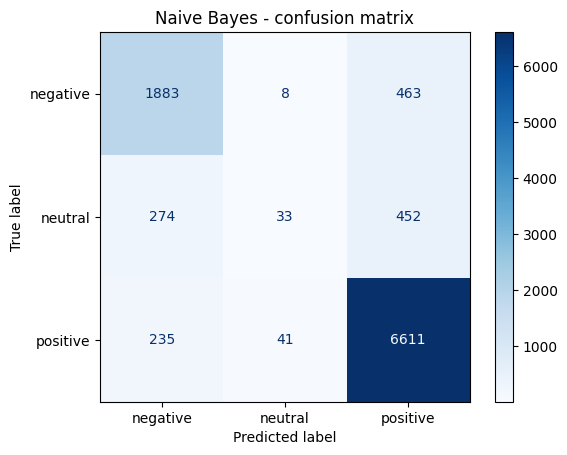

In [10]:
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, predictions, labels=labels)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.title("Naive Bayes - confusion matrix")
plt.show()

## Results

The accuracy is about 85%, but most of it comes from the positive class (around 69% of the sample is positive). Positive and negative reviews get good F1 scores (0.92 and 0.79). Neutral is very bad (recall 0.04): 3-star reviews use the same words as positive and negative ones and there are only a few of them, so Naive Bayes almost never predicts neutral. Using class weights or more neutral reviews would help.